In [1]:
from dataclasses import dataclass
from typing import Callable, Optional

import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm

from sklearn.linear_model import LogisticRegression
from ucimlrepo import fetch_ucirepo 

import pandas as pd
import time
import csv

### Objective: 

Implement the Unadjusted Langevin Algorithm (ULA) for Bayesian inference in a logistic regression model applied to the UCI Musk dataset.




### Bayesian logistic regression framework

Let $N \geqslant 1$. Consider $N$ *i.i.d.* observations $(X_1, Y_1), \dots, (X_N, Y_N)$ where $X_1, \dots, X_N$ are $d$-dimensional input variables and $Y_1, \dots, Y_N$ are binary output responses.

Logistic regression framework amounts to assume the responses to be distributed as Bernoulli random variables such that

$$Y_n \sim \text{Ber}\left( \phi(\theta^\top X_n) \right),\ n\in\{1, \dots, N\},$$

where $\phi(t)=\left( 1+\exp(-t) \right)^{-1},\ t\in\mathbb{R}$.

We consider a Bayesian framework, i.e. $\theta$ is a random variable. Let us choose a prior distribution given by the following density with respect to Lebesgue measure on $\mathbb{R}^d$,

$$p_r(\theta) \propto \exp\left( - (1+ \| \theta \|^2)^{-(1+r)} \right),\ \theta \in \mathbb{R}^d,$$

where $r \in [0,1)$.

Thus, the posterior distribution of $\theta$ is given by the density

$$p_r\left( \theta \vert (X_1, Y_1), \dots, (X_N, Y_N) \right) \propto \exp\left( - \sum_{n=1}^N \ell_n(\theta) - (1+ \| \theta \|^2)^{-(1+r)} \right)$$

where the log-likelihoods are given by

$$\ell_n(\theta) %= - \log \left( \phi\left( (2 Y_n - 1) \theta^\top X_n \right) \right)
= \log\left( 1 + \exp\left( (1 - 2 Y_n) \theta^\top X_n \right) \right).$$

We can now introduce the potential

$$U_r(\theta) = \sum_{n=1}^N \ell_n(\theta) + (1+ \| \theta \|^2)^{-(1+r)} $$

and the associated gradient $\nabla U_r(\theta) = (\partial_1 U_r(\theta), \dots, \partial_d U_r(\theta))^\top$ given by

$$\partial_j U_r(\theta) = \sum_{n=1}^N (1 - 2 Y_n) \phi\left( (1 - 2 Y_n) \theta^\top X_n \right) X_{n,j} + \frac{2 \theta_j}{1+r} (1+ \| \theta \|^2)^{\frac{(1-r)}{(1+r)}},\ j\in\{1, \dots, d\}.$$

In [2]:
@dataclass
class BayesianLogisitcRegression:
    """Bayesian Logisitc Regression"""
    x: np.ndarray
    y: np.ndarray
    r: float = 0.5
    
    
    def __post_init__(self):
        # Check input and output dimensions
        assert self.x.ndim == 2, "Input x is not a matrix"
        assert self.y.ndim == 1, "Output y is not a vector"
        assert self.x.shape[0] == self.y.shape[0], "Dimensions of x and y do not match"
        
        # Compute $1-2Y_n$ 
        y_as_int = self.y.astype(np.int8)
        assert np.all(np.isin(y_as_int, [0, 1])), "Output responses y can not be converted to 0 and 1"
        self._y_rcd = 1 - 2 * y_as_int
        
        # Compute $p=1/(1+r)$ and power $q=(1-r)/(1+r)$ 
        assert 0.0 <= self.r and self.r < 1, "Parameter r is not in [0,1)"
        self._p = 1.0 / (1.0 + self.r)
        self._q = (- self.r) / (1.0 + self.r)
        
    
    def gradient(self, theta: np.ndarray) -> np.ndarray:
        # assert theta.ndim == 1, "Parameter theta is not a vector"
        # assert theta.shape[0] == self.x.shape[1], "Dimensions of x and theta do not match"
        phi = np.vectorize(lambda x: 1.0 / (1.0 + np.exp(-x)) if x > 0 else np.exp(x) / (1.0 + np.exp(x)))
        v = self._y_rcd * phi(self._y_rcd * self.x.dot(theta))
        l_grad = self.x.transpose().dot(v)
        
        pen = 2.0 * self._p * ( 1 + np.dot(theta,theta) )**self._q * theta
        
        return l_grad + pen

### Unadjusted Langevin algorithm

Given a step size $h > 0$ and an initial standard deviation factor $\sigma_0 > 0$, we introduce the sequence $(\theta_k)_{k \geqslant 0}$ defined by the following recursion,

$$\theta_0 = \sigma_0 \xi_0 \quad \text{and} \quad \theta_{k+1} = \theta_k - h \nabla U_r(\theta_k) + \sqrt{2h} \xi_{k+1},\ k \geqslant 0,$$

where $(\xi_k)_{k \geqslant 0}$ is a sequence of *i.i.d.* standard Gaussian random variables in $\mathbb{R}^d$.

In [3]:
@dataclass
class UnadjustedLangevinAlgorithm:
    """Unadjusted Langevin Algorithm"""
    d: int
    potential_gradient: Callable[[np.ndarray], np.ndarray] 
    initial_sd: float = 0.2
    step_size: float = 0.0001
    keep_history: bool = False
    seed: Optional[int] = None
    
    def __post_init__(self):
        # Initial value
        self._rng = np.random.RandomState(self.seed)
        self._theta = self._rng.normal(loc=0, scale=self.initial_sd, size=self.d)
        # Online averaged value
        self._step = 0
        self._theta_bar = self._theta.copy()
        # Keep history if keep_history
        self._history = {
            'theta': [self._theta],
            'theta_bar': [self._theta_bar],
        } if self.keep_history else None
    
    def run(self, n_step: int) -> None:
        # assert n_step > 0, "Parameter n_step must be positive"
        for _ in range(n_step):
            # Update value
            self._theta = ( self._theta - self.step_size * self.potential_gradient(self._theta) + self._rng.normal(loc=0.0, scale=np.sqrt(2.0 * self.step_size), size=self.d))
            # Update averaged value
            self._step += 1
            self._theta_bar = self._theta_bar + (self._theta - self._theta_bar) / self._step
            # Store results in history if needed
            if self.keep_history:
                self._history['theta'].append(self._theta)
                self._history['theta_bar'].append(self._theta_bar)
        
    def theta(self) -> np.ndarray:
        return self._theta
    
    def theta_history(self) -> np.ndarray:
        return self._history

### Musk data
The Musk dataset used in this study is taken from the UCI Machine Learning Repository, with dimensions $N=6598$ and $d=166$. 

DOI: https://doi.org/10.24432/C51608

In [4]:
# Data Preprocessing
X = []
Y = []

with open('musk_csv.csv', newline='') as arx_csv:
    musk_csv = csv.reader(arx_csv, delimiter=',') 
    next(musk_csv)
    for row in musk_csv:
        len_row = len(row)
        float_row = [ float(row[i]) for i in range(3,len_row-1) ]
        X.append(float_row)
        Y.append(float(row[-1]))
X = np.array(X)
Y = np.array(Y)

In [5]:
# Dimensions
d = np.shape(X)[1]
n = np.shape(X)[0]

# Standardized data
for j in range(d):
    X[:,j] = (X[:,j] - np.mean(X[:,j])) / np.std(X[:,j])

print('The dimension is d =', d)
print('The number of observations is N =', n)

The dimension is d = 166
The number of observations is N = 6598


### True value
A reference value for $\theta$ is obtained by running a long ULA trajectory with a very small step size h and a large number of iterations, ensuring high-accuracy approximation.

Run time:  932 seconds for  r = 0.0
Run time:  907 seconds for  r = 0.25
Run time:  894 seconds for  r = 0.5
Run time:  897 seconds for  r = 0.75
Run time:  895 seconds for  r = 0.9999


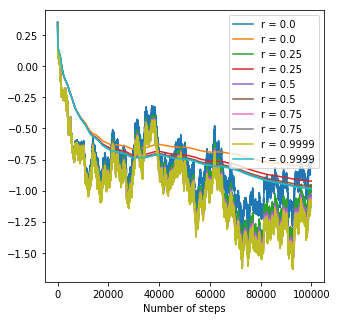

In [6]:
# parameters
r_values = np.array([0, 0.25, 0.5, 0.75, 0.9999]) # HKL parameter
h = 10**(-5) # step size
n_step = 10**(5) # number of steps

# Trajectory
tab_theta = np.zeros((len(r_values), d, n_step+1))
plt.figure(figsize=(5, 5))

for i, r_i in enumerate(r_values):
    start = time.time()
    blr = BayesianLogisitcRegression(x=X, y=Y, r=r_i)

    ula = UnadjustedLangevinAlgorithm(
                d=d,
                step_size = h,
                potential_gradient=lambda theta: blr.gradient(theta),
                keep_history=True,
                seed=0,
    )
    ula.run(n_step)
    tab_theta[i,:,:]=np.concatenate([ula._history['theta']], axis=0).transpose()
    ave_theta = np.concatenate([ula._history['theta_bar']], axis=0).transpose()
    
    # Plot first component and its mean to verify convergence
    label = f'r = {r_i}'
    plt.plot(tab_theta[i,0,:], label=label)
    plt.plot(ave_theta[0], label=label)
    
    end = time.time()
    print('Run time: ', int(end-start), 'seconds for ', label)

plt.xlabel('Number of steps')
plt.legend()
plt.show()

# Save true value
mean_theta = np.mean(tab_theta[:,:,90000:],axis=2) # Cesaro mean
np.save('true_theta.npy', mean_theta)

In [7]:
# Load true value - Cesaro mean
saved_true_value = np.load('true_theta.npy')

### Simulation of $n$ independent trajectories of the ULA

Run time:  2642 seconds for  r = 0
Run time:  2669 seconds for  r = 0.25
Run time:  2706 seconds for  r = 0.5
Run time:  2692 seconds for  r = 0.75
Run time:  2698 seconds for  r = 0.9999


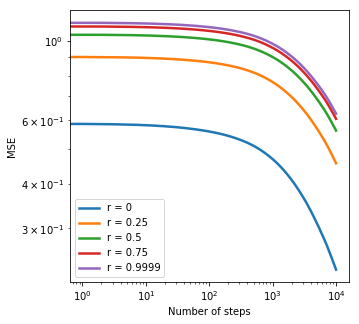

In [8]:
r_values = np.array([0, 0.25, 0.5, 0.75, 0.9999]) # HKL parameter
h = 10**(-5) # step size
n_step = 10**(4) # number of ULA step
n_run = 30 # number of paths

theta = np.zeros((len(r_values), n_run, d, n_step+1))
label = ['r = 0', 'r = 0.25', 'r = 0.5', 'r = 0.75', 'r = 0.9999' ]

for i, r_i in enumerate(r_values):
    start = time.time()
    blr = BayesianLogisitcRegression(x=X, y=Y, r=r_i)

    for n in range(n_run):
        ula = UnadjustedLangevinAlgorithm(
                d=d,
                step_size=h,
                potential_gradient=lambda theta: blr.gradient(theta),
                keep_history=True,
                seed=n+1,
        )
        ula.run(n_step)
        theta[i,n,:,:]=np.concatenate([ula._history['theta_bar']], axis=0).transpose()

    end = time.time()
    #Control time
    print('Run time: ', int(end-start), 'seconds for ', label[i])
    
# Compute Mean Square Error
MSE = np.zeros((len(r_values), n_step+1))

plt.figure(figsize=(5, 5))

for i, r_i in enumerate(r_values):

    for k in range(n_step+1):
        
        for n in range(n_run):
            MSE[i,k] += np.dot(theta[i,n,:,k] - mean_theta[i,:], theta[i,n,:,k] - mean_theta[i,:])/d
        
        MSE[i,k] = MSE[i,k]/n_run
    
    # Plot log(MSE)
    plt.plot( MSE[i,:] , label=label[i] , linewidth=2.5) 

plt.xlabel('Number of steps')
plt.ylabel('MSE')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig('mse_MD.pdf')
plt.show()

# Save trajectories
np.save('trajectories_theta.npy', theta)

### Boxplot of the absolute error at time $K=10^4$

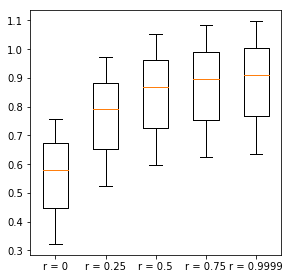

In [9]:
# Load values
theta = np.load('trajectories_theta.npy')

y_boxplot = np.zeros((len(r_values), n_run))
for i in range(len(r_values)):
    y_boxplot[i,:] =  np.abs(theta[i,:,0,-1] - mean_theta[i,0] ) # 
plt.figure(figsize=(4.5, 4.5))
plt.boxplot(np.transpose(y_boxplot), labels=['r = 0', 'r = 0.25','r = 0.5', 'r = 0.75', 'r = 0.9999']);

plt.savefig('boxplot_MD.pdf')
plt.show()